In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np 

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

def carregar_e_agregar_consumos(path_xlsx: str, intervalo_minutos: int = 15):
    """
    Lê um ficheiro Excel com a estrutura mostrada (linhas de 'Dados Globais' no topo),
    encontra automaticamente o cabeçalho da tabela ('Data', 'Hora', 'Consumo registado (kW)', 'Estado'),
    converte potência (kW) em energia (kWh) pelo intervalo indicado e devolve um DataFrame diário.
    """
    path = Path(path_xlsx)

    # 1) Ler tudo sem cabeçalho (para podermos localizar a linha do header real)
    df_raw = pd.read_excel(path, header=None)    

    # 2) Encontrar a linha que contém a palavra 'Data' na 1ª coluna
    mask_header = df_raw.iloc[:, 0].astype(str).str.strip().str.lower().eq("data")
    if not mask_header.any():
        raise ValueError("Não encontrei a linha de cabeçalho com 'Data' na primeira coluna.")

    header_row = mask_header.idxmax()  # primeira ocorrência
    cols = df_raw.iloc[header_row].tolist()

    # 3) Construir o DataFrame limpo a partir da linha seguinte ao cabeçalho
    df = df_raw.iloc[header_row + 1:].copy()
    df.columns = cols

    # 4) Manter apenas colunas relevantes (ignora 'Estado' se existir)
    # Tentar localizar a coluna do consumo (nome costuma conter 'Consumo' e '(kW)')
    consumo_col_candidates = [c for c in df.columns if isinstance(c, str) and ("consumo" in c.lower())]
    if not consumo_col_candidates:
        raise ValueError("Não encontrei a coluna de consumo (ex.: 'Consumo registado (kW)').")
    consumo_col = consumo_col_candidates[0]

    # 5) Limpeza de linhas vazias
    df = df[~df["Data"].isna()].copy()
    df = df[~df["Hora"].isna()].copy()

    # 6) Normalizar valores numéricos (suporta vírgula decimal)
    df[consumo_col] = (
        df[consumo_col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

    # 7) Construir timestamp
    # Se 'Data' vier tipo 'YYYY/MM/DD' e 'Hora' 'HH:MM'
    df["timestamp"] = pd.to_datetime(df["Data"].astype(str) + " " + df["Hora"].astype(str), errors="coerce")
    df = df.dropna(subset=["timestamp"]).copy()

    # 8) Converter kW -> kWh pelo intervalo (15 min => 0.25 h)
    horas = intervalo_minutos / 60.0
    df["energia_kwh"] = df[consumo_col] * horas

    # 9) Agregar por dia
    df["dia"] = df["timestamp"].dt.date
    diarios = (
        df.groupby("dia", as_index=False)["energia_kwh"]
        .sum()
        .rename(columns={"energia_kwh": "consumo_diario_kwh"})
    )

    # 10) (Opcional) algumas estatísticas úteis
    total_mes_kwh = diarios["consumo_diario_kwh"].sum()
    media_diaria_kwh = diarios["consumo_diario_kwh"].mean()

    return df, diarios, {"total_mes_kwh": float(total_mes_kwh), "media_diaria_kwh": float(media_diaria_kwh)}


import pandas as pd
from pathlib import Path

def consumos_diarios(path_xlsx: str, clip_negativos: bool = False) -> pd.DataFrame:
    """
    Lê o XLSX (uma folha), remove linhas não relevantes, calcula consumos diários por período
    e ATTRIBUI o consumo ao DIA ANTERIOR (leitura às 00:00).

    Retorna colunas:
      data (dia a que o consumo pertence), vazio_kwh, ponta_kwh, cheias_kwh, total_kwh
    """
    path = Path(path_xlsx)

    # 1) Ler tudo sem header para localizar o cabeçalho real
    df_raw = pd.read_excel(path, header=None)

    # 2) Encontrar a linha do cabeçalho (procura por "Data da Leitura" ou "Data")
    header_row = None
    for i in range(len(df_raw)):
        row = df_raw.iloc[i].astype(str).str.strip().str.lower().tolist()
        if any("data da leitura" in s for s in row) or (str(df_raw.iloc[i,0]).strip().lower() in ("data", "data da leitura")):
            header_row = i
            break
    if header_row is None:
        raise ValueError("Não encontrei a linha de cabeçalho (ex.: 'Data da Leitura').")

    # 3) Ler novamente com o cabeçalho certo
    df = pd.read_excel(path, header=header_row)

    # 4) Normalizar nomes das colunas
    rename_map = {}
    for col in df.columns:
        c = str(col).strip().lower()
        if "data" in c and "leitura" in c or c == "data":
            rename_map[col] = "data"
        elif "vazio" in c:
            rename_map[col] = "vazio"
        elif "ponta" in c:
            rename_map[col] = "ponta"
        elif "cheia" in c:  # cobre "cheia"/"cheias"
            rename_map[col] = "cheias"
    df = df.rename(columns=rename_map)

    # 5) Manter apenas as colunas necessárias
    cols = ["data", "vazio", "ponta", "cheias"]
    if any(c not in df.columns for c in cols):
        faltam = [c for c in cols if c not in df.columns]
        raise ValueError(f"Faltam colunas esperadas: {faltam}")

    df = df[cols].copy()

    # 6) Tipos e limpeza básica
    df["data"] = pd.to_datetime(df["data"], dayfirst = True, errors="coerce")
    for c in ["vazio", "ponta", "cheias"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["data", "vazio", "ponta", "cheias"])

    # 7) Ordenar por data ASC (acumulados)
    df = df.sort_values("data").reset_index(drop=True)

    # 8) Diferenças dia a dia (consumo entre D-1 24:00 e D 00:00)
    diffs = df[["vazio", "ponta", "cheias"]].diff()
    diffs.columns = [f"{c}_kwh" for c in diffs.columns]

    # 9) Atribuir o consumo ao DIA ANTERIOR:
    #    a leitura de D (linha i) menos D-1 (linha i-1) pertence ao dia D-1.
    out = pd.concat([df[["data"]], diffs], axis=1).dropna().reset_index(drop=True)
    out["data"] = out["data"] - pd.Timedelta(days=1)

    if clip_negativos:
        for c in ["vazio_kwh", "ponta_kwh", "cheias_kwh"]:
            out[c] = out[c].clip(lower=0)

    out["total_kwh"] = out[["vazio_kwh", "ponta_kwh", "cheias_kwh"]].sum(axis=1)

    # 10) Opcional: garantir inteiros/quebras razoáveis
    # out[["vazio_kwh","ponta_kwh","cheias_kwh","total_kwh"]] = out[...].round(3)

    return out



## a hora 00 corresponde ao dia anterior MUDAR 
    

Resumo:
Total do mês (agregado): 4039.26 kWh
Média diária (agregado): 15.48 kWh
Leituras diárias shape: (61, 5)
Colunas leituras: ['data', 'vazio_kwh', 'ponta_kwh', 'cheias_kwh', 'total_kwh']


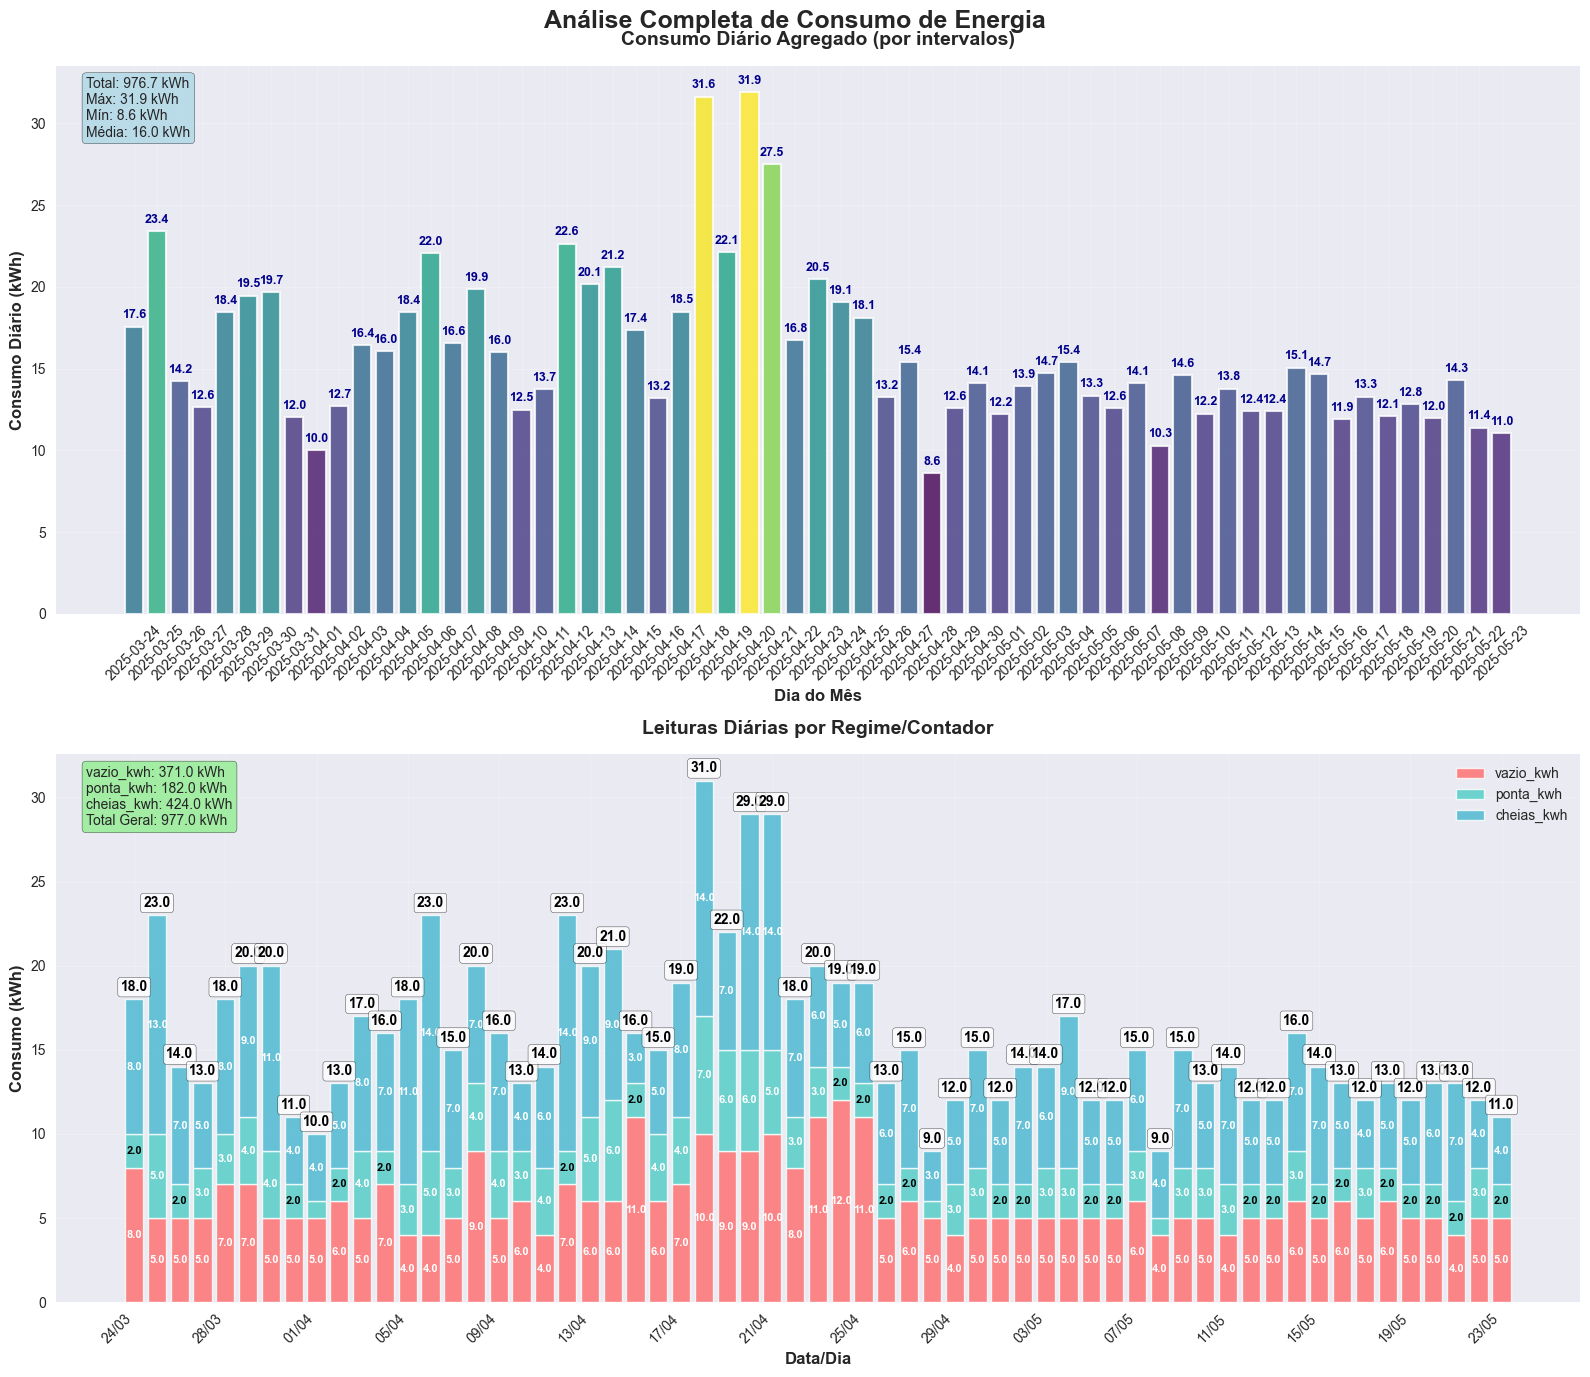


--- Resumo Consumo Agregado ---
Total mensal: 4039.26 kWh
Média diária: 15.48 kWh

--- Resumo Leituras Diárias ---
Colunas encontradas: ['vazio_kwh', 'ponta_kwh', 'cheias_kwh', 'total_kwh']
vazio_kwh: 371.00 kWh
ponta_kwh: 182.00 kWh
cheias_kwh: 424.00 kWh
total_kwh: 977.00 kWh

Estrutura dados leituras: (61, 5)
Primeiras linhas leituras:
        data  vazio_kwh  ponta_kwh  cheias_kwh  total_kwh
0 2025-03-24        8.0        2.0         8.0       18.0
1 2025-03-25        5.0        5.0        13.0       23.0
2 2025-03-26        5.0        2.0         7.0       14.0
3 2025-03-27        5.0        3.0         5.0       13.0
4 2025-03-28        7.0        3.0         8.0       18.0


In [52]:
if __name__ == "__main__":
    import numpy as np  # Adicionar import necessário
    
    # ----------------- USO -----------------
    caminho_agg = "merged_consumos.xlsx"  
    caminho = 'merged_leituras.xlsx' 
    intervalo = 15  # minutos
    
    # Obter dados dos dois tipos
    df_linhas, df_diarios, stats = carregar_e_agregar_consumos(caminho_agg, intervalo_minutos=intervalo)
    df_leituras = consumos_diarios(caminho, clip_negativos=False)

    #df.to_excel("saida.xlsx", index=False) 


    
    # ----------------- DEFINE DATE RANGE -----------------
    start_date = "2025-03-24"
    end_date   = "2025-05-23"
    
    # Garantir que as colunas de data são datetime
    if "dia" in df_diarios.columns:
        df_diarios["dia"] = pd.to_datetime(df_diarios["dia"])
    if "data" in df_leituras.columns:
        df_leituras["data"] = pd.to_datetime(df_leituras["data"], errors="coerce")
    
    # Filtrar pelos intervalos de datas
    mask_diarios = (df_diarios["dia"] >= start_date) & (df_diarios["dia"] <= end_date)
    df_diarios = df_diarios.loc[mask_diarios].reset_index(drop=True)
    
    if "data" in df_leituras.columns:
        mask_leituras = (df_leituras["data"] >= start_date) & (df_leituras["data"] <= end_date)
        df_leituras = df_leituras.loc[mask_leituras].reset_index(drop=True)

    
    print("Resumo:")
    print(f"Total do mês (agregado): {stats['total_mes_kwh']:.2f} kWh")
    print(f"Média diária (agregado): {stats['media_diaria_kwh']:.2f} kWh")
    print(f"Leituras diárias shape: {df_leituras.shape}")
    print(f"Colunas leituras: {list(df_leituras.columns)}")
    
    # Criar figura com 2 subplots
    plt.style.use('seaborn-v0_8')
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14))
    fig.suptitle('Análise Completa de Consumo de Energia', fontsize=18, fontweight='bold', y=0.98)
    
    # ===================== GRÁFICO 1: CONSUMO DIÁRIO AGREGADO =====================
    valores_diarios = df_diarios["consumo_diario_kwh"]
    norm_diarios = plt.Normalize(vmin=valores_diarios.min(), vmax=valores_diarios.max())
    colors_diarios = plt.cm.viridis(norm_diarios(valores_diarios))
    
    bars1 = ax1.bar(df_diarios["dia"].astype(str), 
                    df_diarios["consumo_diario_kwh"], 
                    color=colors_diarios,
                    edgecolor='white',
                    linewidth=1.5,
                    alpha=0.8)
    
    # Valores no topo das barras
    for bar, valor in zip(bars1, valores_diarios):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + valores_diarios.max() * 0.01,
                f'{valor:.1f}',
                ha='center', va='bottom',
                fontsize=9, fontweight='bold',
                color='darkblue')
    


    # Personalizar gráfico 1
    ax1.set_xlabel("Dia do Mês", fontsize=12, fontweight='bold')
    ax1.set_ylabel("Consumo Diário (kWh)", fontsize=12, fontweight='bold')
    ax1.set_title("Consumo Diário Agregado (por intervalos)", fontsize=14, fontweight='bold', pad=15)
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax1.set_axisbelow(True)
    
    # Info box para gráfico 1
    textstr1 = f'Total: {valores_diarios.sum():.1f} kWh\nMáx: {valores_diarios.max():.1f} kWh\nMín: {valores_diarios.min():.1f} kWh\nMédia: {valores_diarios.mean():.1f} kWh'
    props1 = dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
    ax1.text(0.02, 0.98, textstr1, transform=ax1.transAxes, fontsize=10,
            verticalalignment='top', bbox=props1)
    
    # ===================== GRÁFICO 2: LEITURAS DIÁRIAS =====================
    # Identificar colunas de dados (excluindo 'data' se existir)
    colunas_dados = [col for col in df_leituras.columns if col.lower() not in ['data', 'dia']]
    
    if colunas_dados:
        # Preparar dados para o gráfico
        if 'data' in df_leituras.columns:
            x_labels = df_leituras['data'].dt.strftime('%d/%m') if hasattr(df_leituras['data'], 'dt') else df_leituras['data'].astype(str)
        elif 'dia' in df_leituras.columns:
            x_labels = df_leituras['dia'].astype(str)
        else:
            x_labels = range(len(df_leituras))
        
        x_pos = range(len(df_leituras))
        
        # Cores para diferentes colunas/regimes
        cores_regimes = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
        
        if len(colunas_dados) == 1:
            # Caso simples: uma só coluna
            coluna = colunas_dados[0]
            valores = df_leituras[coluna]
            
            # Gradiente baseado nos valores
            norm = plt.Normalize(vmin=valores.min(), vmax=valores.max())
            colors = plt.cm.plasma(norm(valores))
            
            bars2 = ax2.bar(x_pos, valores, 
                           color=colors,
                           edgecolor='white',
                           linewidth=1.5,
                           alpha=0.8,
                           label=coluna)
            
            # Valores no topo
            for i, (bar, valor) in enumerate(zip(bars2, valores)):
                height = bar.get_height()
                ax2.text(bar.get_x() + bar.get_width()/2., height + valores.max() * 0.01,
                       f'{valor:.1f}',
                       ha='center', va='bottom',
                       fontsize=9, fontweight='bold',
                       color='darkblue')
            
            # Estatísticas
            media_leituras = valores.mean()
            ax2.axhline(y=media_leituras, color='orange', linestyle='--', linewidth=2, alpha=0.7)
            ax2.text(len(df_leituras)/2, media_leituras + valores.max() * 0.03, 
                   f'Média: {media_leituras:.1f} kWh', 
                   ha='center', va='bottom', color='orange', fontweight='bold',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
            
            textstr2 = f'Total: {valores.sum():.1f} kWh\nMáx: {valores.max():.1f} kWh\nMín: {valores.min():.1f} kWh\nMédia: {media_leituras:.1f} kWh'
            
        else:
            # Múltiplas colunas: barras empilhadas APENAS com os 3 regimes (excluir 'total')
            # Excluir coluna 'total' ou similar
            colunas_para_plot = [col for col in colunas_dados if col.lower() not in ['total', 'soma', 'sum']]
            
            if not colunas_para_plot:
                # Se só existe coluna 'total', tratar como caso simples
                coluna = colunas_dados[0]
                valores = df_leituras[coluna]
                
                norm = plt.Normalize(vmin=valores.min(), vmax=valores.max())
                colors = plt.cm.plasma(norm(valores))
                
                bars2 = ax2.bar(x_pos, valores, 
                               color=colors,
                               edgecolor='white',
                               linewidth=1.5,
                               alpha=0.8,
                               label=coluna)
                
                # Valores no topo
                for i, (bar, valor) in enumerate(zip(bars2, valores)):
                    height = bar.get_height()
                    ax2.text(bar.get_x() + bar.get_width()/2., height + valores.max() * 0.01,
                           f'{valor:.1f}',
                           ha='center', va='bottom',
                           fontsize=9, fontweight='bold',
                           color='darkblue')
                
                textstr2 = f'Total: {valores.sum():.1f} kWh\nMáx: {valores.max():.1f} kWh\nMín: {valores.min():.1f} kWh'
            
            else:
                # Garantir máximo 3 colunas para plot
                colunas_para_plot = colunas_para_plot[:3]
                
                bottom = np.zeros(len(df_leituras))
                
                # Plotar APENAS os regimes (máximo 3)
                for i, coluna in enumerate(colunas_para_plot):
                    valores = df_leituras[coluna]
                    cor = cores_regimes[i % len(cores_regimes)]
                    
                    bars = ax2.bar(x_pos, valores, bottom=bottom,
                                 color=cor, alpha=0.8, 
                                 label=coluna,
                                 edgecolor='white', linewidth=1)
                    
                    # Valores dentro das barras (se houver espaço)
                    for j, (bar, valor) in enumerate(zip(bars, valores)):
                        if valor > (df_leituras[colunas_para_plot].sum(axis=1).max() * 0.05):
                            height = bar.get_height()
                            ax2.text(bar.get_x() + bar.get_width()/2., 
                                   bottom[j] + height/2,
                                   f'{valor:.1f}',
                                   ha='center', va='center',
                                   fontsize=8, fontweight='bold',
                                   color='white' if valor > df_leituras[colunas_para_plot].sum(axis=1).max() * 0.08 else 'black')
                    
                    bottom += valores
                
                # TOTAL NUMÉRICO no topo das 3 barras empilhadas (NÃO uma barra adicional)
                # Usar coluna 'total' se existir, senão calcular soma dos regimes plotados
                if 'total' in df_leituras.columns:
                    totais = df_leituras['total']
                else:
                    totais = df_leituras[colunas_para_plot].sum(axis=1)
                
                # Colocar texto do total em cima das barras empilhadas
                for i, total in enumerate(totais):
                    ax2.text(i, bottom[i] + totais.max() * 0.01,
                           f'{total:.1f}',
                           ha='center', va='bottom',
                           fontsize=10, fontweight='bold',
                           color='black',
                           bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))
                
                # Info box com totais por regime (só os plotados)
                textstr_lines = [f'{col}: {df_leituras[col].sum():.1f} kWh' for col in colunas_para_plot]
                textstr_lines.append(f'Total Geral: {totais.sum():.1f} kWh')
                textstr2 = '\n'.join(textstr_lines)
                
                # Legenda (só dos regimes plotados)
                ax2.legend(loc='upper right', framealpha=0.9, fontsize=10)
        
        # Personalizar gráfico 2
        ax2.set_xlabel("Data/Dia", fontsize=12, fontweight='bold')
        ax2.set_ylabel("Consumo (kWh)", fontsize=12, fontweight='bold')
        ax2.set_title("Leituras Diárias por Regime/Contador", fontsize=14, fontweight='bold', pad=15)
        
        # Configurar eixo x
        ax2.set_xticks(x_pos[::max(1, len(x_pos)//15)])  # Mostrar no máximo 15 labels
        ax2.set_xticklabels([x_labels[i] for i in range(0, len(x_labels), max(1, len(x_labels)//15))], 
                           rotation=45, ha="right")
        
    else:
        # Se não há dados de leituras
        ax2.text(0.5, 0.5, 'Dados de leituras diárias não disponíveis\nou sem colunas válidas', 
                ha='center', va='center', transform=ax2.transAxes, 
                fontsize=14, bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow"))
        ax2.set_title("Leituras Diárias (Dados não disponíveis)", fontsize=14, fontweight='bold', pad=15)
        textstr2 = "Sem dados"
    
    # Grid e styling para gráfico 2
    ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax2.set_axisbelow(True)
    
    # Info box para gráfico 2
    props2 = dict(boxstyle='round', facecolor='lightgreen', alpha=0.8)
    ax2.text(0.02, 0.98, textstr2, transform=ax2.transAxes, fontsize=10,
            verticalalignment='top', bbox=props2)
    
    # Melhorar aparência geral
    for ax in [ax1, ax2]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    plt.subplots_adjust(top=0.94)
    plt.show()
    
    # Opcional: salvar os gráficos
    # plt.savefig('analise_consumo_completa.png', dpi=300, bbox_inches='tight')
    
    # Imprimir resumos
    print(f"\n--- Resumo Consumo Agregado ---")
    print(f"Total mensal: {stats['total_mes_kwh']:.2f} kWh")
    print(f"Média diária: {stats['media_diaria_kwh']:.2f} kWh")
    
    if colunas_dados:
        print(f"\n--- Resumo Leituras Diárias ---")
        print(f"Colunas encontradas: {colunas_dados}")
        for col in colunas_dados:
            total_col = df_leituras[col].sum()
            print(f"{col}: {total_col:.2f} kWh")
    
    print(f"\nEstrutura dados leituras: {df_leituras.shape}")
    if len(df_leituras) > 0:
        print("Primeiras linhas leituras:")
        print(df_leituras.head())

In [2]:
df = carregar_e_agregar_consumos('merged_consumos.xlsx')

In [3]:
df

(             Data   Hora  Consumo registado (kW) Estado ficheiro  \
 1      2025/01/01  00:15                   0.564   Real      c01   
 2      2025/01/01  00:30                   0.480   Real      c01   
 3      2025/01/01  00:45                   0.336   Real      c01   
 4      2025/01/01  01:00                   0.440   Real      c01   
 5      2025/01/01  01:15                   0.428   Real      c01   
 ...           ...    ...                     ...    ...      ...   
 24958  2025/09/18  00:30                   0.432   Real      c09   
 24959  2025/09/18  00:45                   0.500   Real      c09   
 24960  2025/09/18  01:00                   0.360   Real      c09   
 24961  2025/09/18  01:15                   0.308   Real      c09   
 24962  2025/09/18  01:30                   1.076   Real      c09   
 
                 timestamp  energia_kwh         dia  
 1     2025-01-01 00:15:00        0.141  2025-01-01  
 2     2025-01-01 00:30:00        0.120  2025-01-01  
 3     2